# Práctica Final NLP — Exploración del corpus

In [16]:
!pip install gensim wordcloud --quiet

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from gensim.models import Word2Vec
from nltk import ngrams
from nltk.probability import FreqDist
from sklearn.manifold import TSNE
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
import urllib.request

files = [
    "reviews_Clothing_Shoes_and_Jewelry_5.json.gz",
    "reviews_Office_Products_5.json.gz",
    "reviews_Video_Games_5.json.gz"
]

base_url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/"

for f in files:
    print(f"Descargando {f}...")
    urllib.request.urlretrieve(base_url + f, f)
    print("  OK")

Descargando reviews_Clothing_Shoes_and_Jewelry_5.json.gz...
  OK
Descargando reviews_Office_Products_5.json.gz...
  OK
Descargando reviews_Video_Games_5.json.gz...
  OK


## Carga de datos

Para este ejercicio se utilizan reviews de tres categorías de productos de Amazon:
- **Clothing, Shoes and Jewelry**
- **Office Products**  
- **Video Games**

Los datos se han descargado de: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/
y se trabaja con un subset de 10.000 reviews por categoría (30.000 en total)
para evitar problemas de memoria.

In [19]:
df_clothing   = pd.read_json("reviews_Clothing_Shoes_and_Jewelry_5.json.gz", lines=True, compression='gzip')
df_office     = pd.read_json("reviews_Office_Products_5.json.gz", lines=True, compression='gzip')
df_videogames = pd.read_json("reviews_Video_Games_5.json.gz", lines=True, compression='gzip')

print("Clothing:", df_clothing.shape)
print("Office:", df_office.shape)
print("Video Games:", df_videogames.shape)

Clothing: (278677, 9)
Office: (53258, 9)
Video Games: (231780, 9)


## Etiquetado de sentimiento y construcción del corpus

In [20]:
df_clothing['sentiment']   = df_clothing['overall'].apply(lambda x: 0 if x < 3 else 1)
df_office['sentiment']     = df_office['overall'].apply(lambda x: 0 if x < 3 else 1)
df_videogames['sentiment'] = df_videogames['overall'].apply(lambda x: 0 if x < 3 else 1)

df_clothing   = df_clothing[['reviewText', 'overall', 'sentiment']].dropna()
df_office     = df_office[['reviewText', 'overall', 'sentiment']].dropna()
df_videogames = df_videogames[['reviewText', 'overall', 'sentiment']].dropna()

N = 10000
df = pd.concat([
    df_clothing.sample(N, random_state=42),
    df_office.sample(N, random_state=42),
    df_videogames.sample(N, random_state=42)
]).reset_index(drop=True)

print("Corpus total:", df.shape)
print(df['sentiment'].value_counts())

Corpus total: (30000, 3)
sentiment
1    27302
0     2698
Name: count, dtype: int64


## Cardinalidad del vocabulario

In [21]:
all_words = ' '.join(df['reviewText']).lower().split()
vocab = set(all_words)
print(f"Total de tokens: {len(all_words):,}")
print(f"Vocabulario único (cardinalidad): {len(vocab):,}")

Total de tokens: 4,085,008
Vocabulario único (cardinalidad): 173,179


## Distribución de reviews por número de estrellas

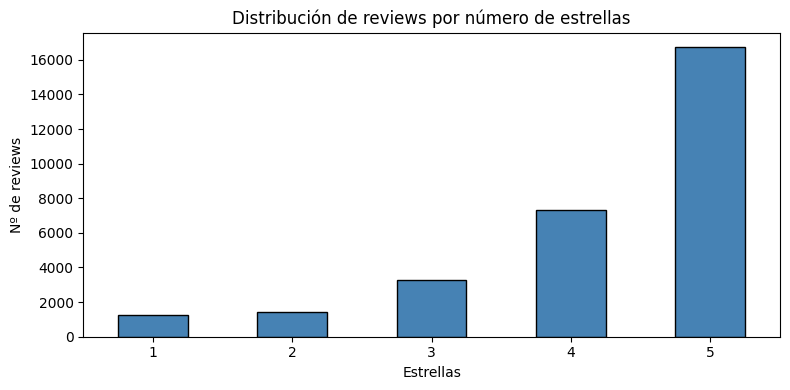

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
df['overall'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribución de reviews por número de estrellas')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Nº de reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Reviews positivas vs negativas

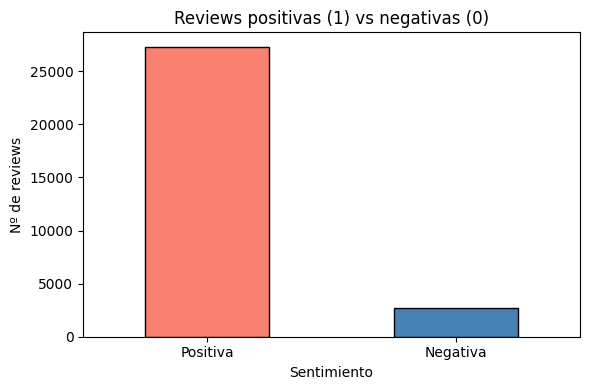

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='black')
ax.set_title('Reviews positivas (1) vs negativas (0)')
ax.set_xlabel('Sentimiento')
ax.set_ylabel('Nº de reviews')
ax.set_xticklabels(['Positiva', 'Negativa'], rotation=0)
plt.tight_layout()
plt.show()

## N-grams más frecuentes

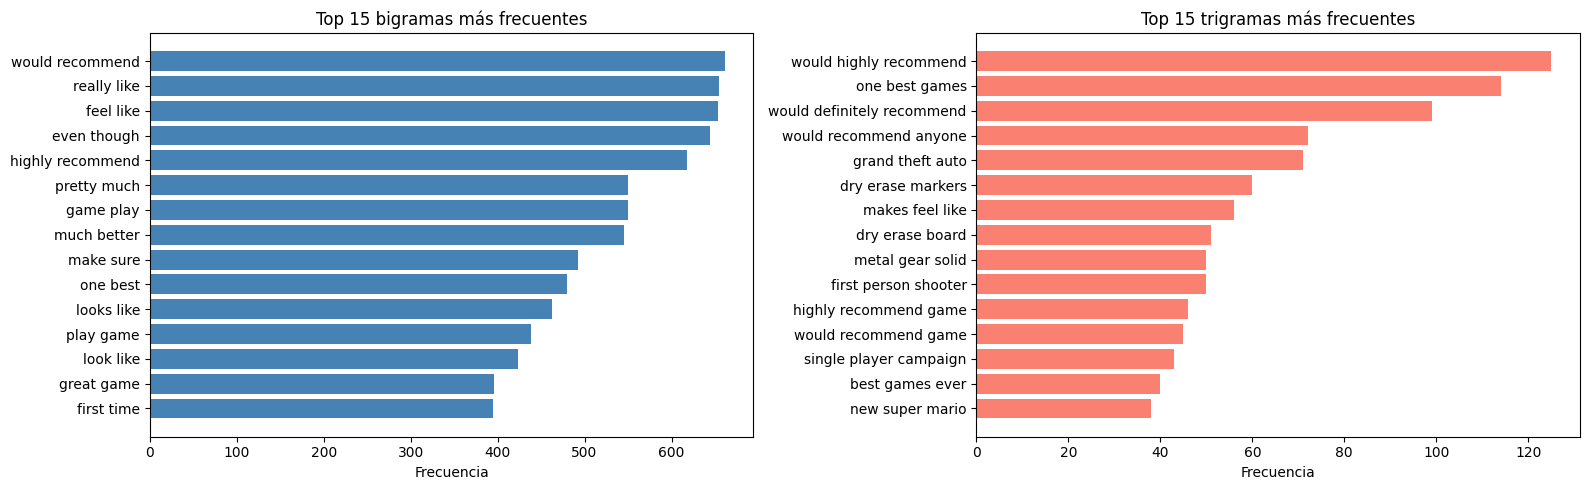

In [24]:
from nltk.corpus import stopwords

sw = set(stopwords.words('english'))

def get_ngrams(corpus, n, top_k=15):
    tokens = [w for w in ' '.join(corpus).lower().split()
              if w not in sw and w.isalpha()]
    n_grams = list(ngrams(tokens, n))
    return FreqDist(n_grams).most_common(top_k)

bigrams  = get_ngrams(df['reviewText'], 2)
trigrams = get_ngrams(df['reviewText'], 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_bi = [' '.join(g) for g, _ in bigrams]
counts_bi = [c for _, c in bigrams]
axes[0].barh(labels_bi[::-1], counts_bi[::-1], color='steelblue')
axes[0].set_title('Top 15 bigramas más frecuentes')
axes[0].set_xlabel('Frecuencia')

labels_tri = [' '.join(g) for g, _ in trigrams]
counts_tri = [c for _, c in trigrams]
axes[1].barh(labels_tri[::-1], counts_tri[::-1], color='salmon')
axes[1].set_title('Top 15 trigramas más frecuentes')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

## Nube de palabras

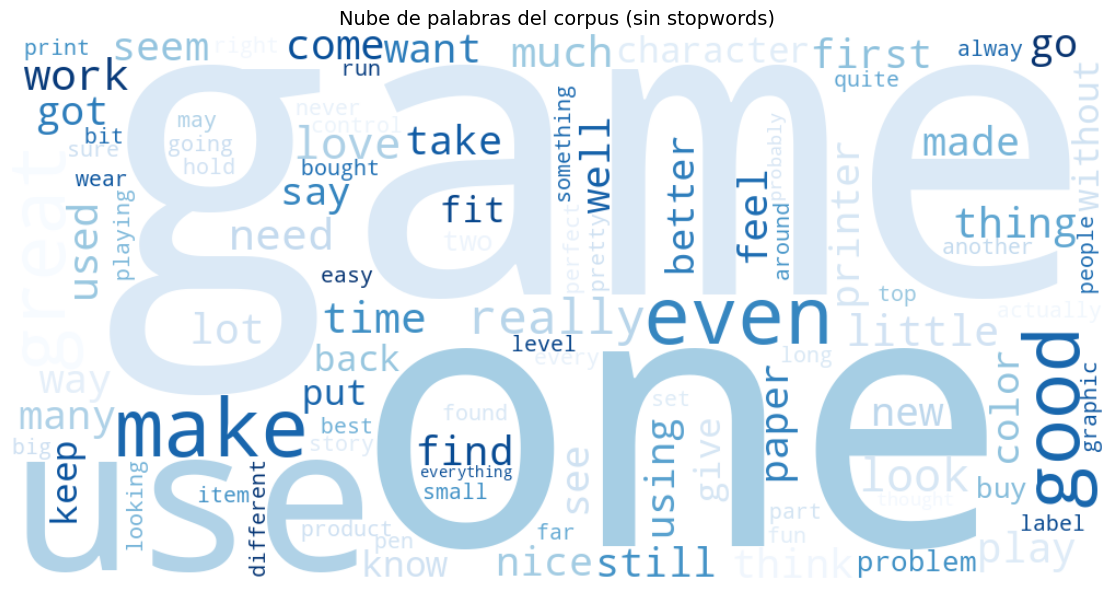

In [25]:
text_for_cloud = ' '.join([
    w for w in ' '.join(df['reviewText']).lower().split()
    if w not in sw and w.isalpha()
])

wc = WordCloud(width=1000, height=500, background_color='white',
               max_words=100, colormap='Blues').generate(text_for_cloud)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras del corpus (sin stopwords)', fontsize=14)
plt.tight_layout()
plt.show()

## Word Embeddings — Word2Vec

In [26]:
sentences = [
    [w for w in review.lower().split() if w.isalpha() and w not in sw]
    for review in df['reviewText']
]

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    seed=42
)

print("Vocabulario del modelo W2V:", len(w2v_model.wv))
print("\nPalabras más similares a 'game':", w2v_model.wv.most_similar('game', topn=5))
print("Palabras más similares a 'product':", w2v_model.wv.most_similar('product', topn=5))

Vocabulario del modelo W2V: 13742

Palabras más similares a 'game': [('gameplay', 0.7586105465888977), ('addicting', 0.7452110648155212), ('games', 0.7448755502700806), ('ufc', 0.7391083836555481), ('inferno', 0.735493004322052)]
Palabras más similares a 'product': [('item', 0.7294325232505798), ('advertised', 0.7278963327407837), ('condition', 0.7125087380409241), ('seller', 0.6973639726638794), ('complimentary', 0.6917171478271484)]


## Visualización en 2D con t-SNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


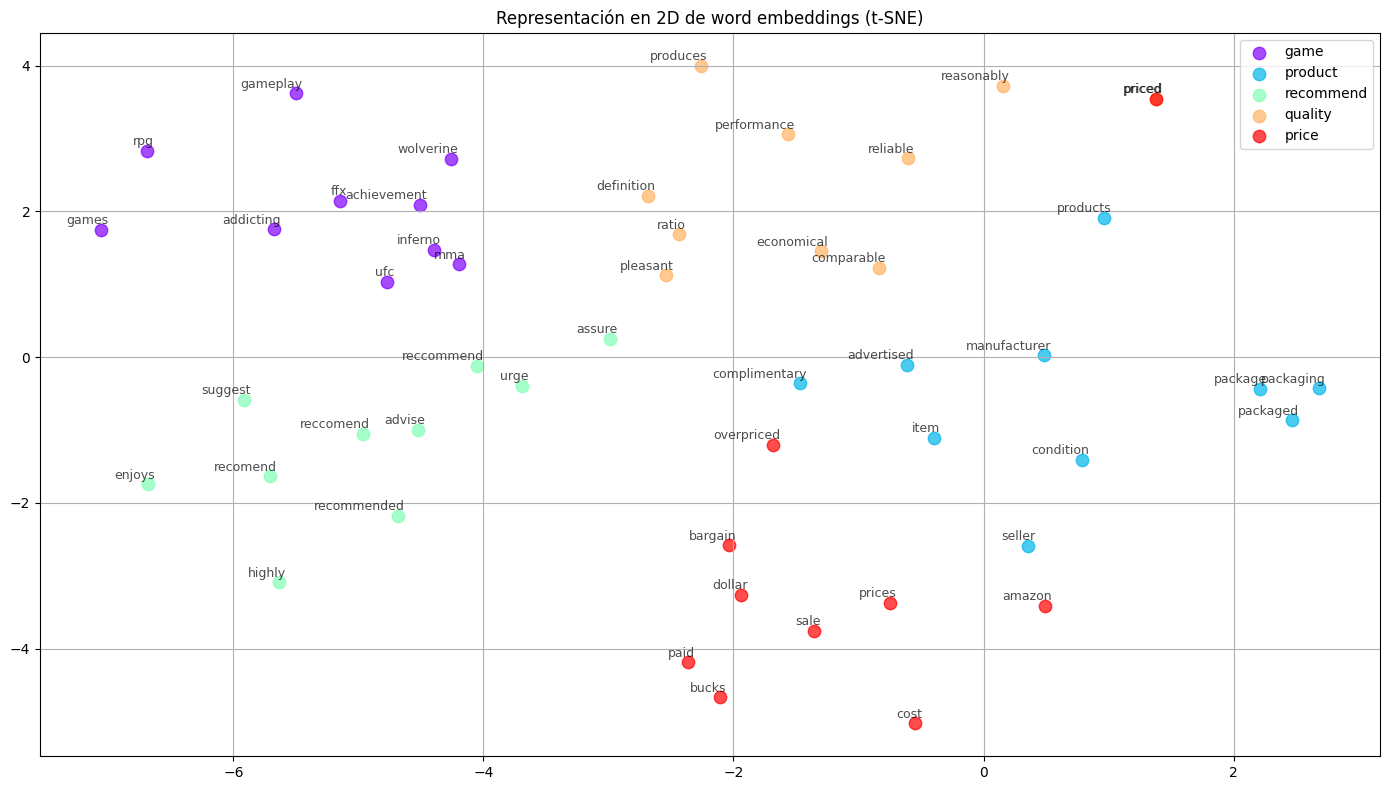

In [27]:
keys = ['game', 'product', 'recommend', 'quality', 'price']

embedding_clusters = []
word_clusters = []

for word in keys:
    embeddings = []
    words = []
    for similar_word, _ in w2v_model.wv.most_similar(word, topn=10):
        words.append(similar_word)
        embeddings.append(w2v_model.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape

tsne_model = TSNE(perplexity=15, n_components=2, init='pca',
                  n_iter=3500, random_state=42)
embeddings_2d = np.array(
    tsne_model.fit_transform(embedding_clusters.reshape(n * m, k))
).reshape(n, m, 2)

def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(14, 8))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:, 0]
        y = embeddings[:, 1]
        plt.scatter(x, y, c=[color], alpha=a, label=label, s=80)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.7, xy=(x[i], y[i]),
                         xytext=(5, 2), textcoords='offset points',
                         ha='right', va='bottom', size=9)
    plt.legend(loc='best')
    plt.grid(True)
    plt.title('Representación en 2D de word embeddings (t-SNE)')
    plt.tight_layout()
    plt.show()

tsne_plot_similar_words(keys, embeddings_2d, word_clusters)

## Conclusiones de la exploración

A partir del análisis exploratorio realizado se pueden extraer las siguientes conclusiones:

- El corpus de trabajo está compuesto por **30.000 reviews** de tres categorías de Amazon
  (Clothing, Office Products y Video Games), con un vocabulario único de **173.179 palabras**.

- Existe un **fuerte desbalanceo de clases**: el 91% de las reviews son positivas (≥3 estrellas)
  frente al 9% de negativas. Este desequilibrio deberá tenerse en cuenta en la etapa de modelado,
  aplicando técnicas de balanceo de clases.

- La distribución por estrellas muestra que las reviews de 5 estrellas son las más frecuentes,
  seguidas de las de 4 estrellas, lo cual es coherente con el sesgo de positividad habitual
  en plataformas de e-commerce.

- Los **n-grams más frecuentes** revelan expresiones de recomendación ("would recommend",
  "would highly recommend") y términos específicos de cada categoría ("grand theft auto",
  "dry erase markers"), lo que confirma que el corpus mezcla dominios temáticos distintos.

- La visualización t-SNE de los **word embeddings** (Word2Vec) muestra que el modelo
  ha aprendido relaciones semánticas coherentes: palabras relacionadas con precio
  (*cost*, *bargain*, *overpriced*) se agrupan juntas, al igual que las de videojuegos
  (*gameplay*, *fifa*, *borderlands*) y las de recomendación (*advise*, *suggest*, *urge*).

- Como próximo paso, es necesario aplicar un pipeline de preprocesado que elimine stopwords,
  signos de puntuación y normalice el texto antes de entrenar el modelo de clasificación.